<a href="https://colab.research.google.com/github/enrico-s01/My-Git/blob/main/ResNetvsNeuralODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
%pip install torchdiffeq
from torchdiffeq import odeint, odeint_adjoint

# Data Download

In [ ]:

os.makedirs("data", exist_ok=True)
print("OK: cartella data/ pronta")


OK: cartella data/ pronta


In [ ]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human%2Bactivity%2Brecognition%2Busing%2Bsmartphones.zip"
ZIP_PATH = "data/uci_har.zip"

if not os.path.exists(ZIP_PATH):
    print("ZIP non trovato -> lo scarico...")
    !wget -q -O "$ZIP_PATH" "$DATA_URL"
else:
    print("ZIP già presente:", ZIP_PATH)

!ls -lah data


ZIP non trovato -> lo scarico...
total 59M
drwxr-xr-x 2 root root 4.0K Jan 16 11:31 .
drwxr-xr-x 1 root root 4.0K Jan 16 11:31 ..
-rw-r--r-- 1 root root  59M Jan 16 11:32 uci_har.zip


In [ ]:
ZIP_PATH = "data/uci_har.zip"

# Se non esiste già activity_labels.txt in qualche sottocartella di data/, unzip
matches = glob.glob("data/**/activity_labels.txt", recursive=True)

if len(matches) == 0:
    print("Dataset NON scompattato -> eseguo unzip...")
    # -n = non sovrascrive se trova già file esistenti
    !unzip -q -n "$ZIP_PATH" -d data
else:
    print("Dataset sembra già scompattato -> non faccio unzip.")

# finds activity labels
matches = glob.glob("data/**/activity_labels.txt", recursive=True)
print("Trovati activity_labels.txt:", matches[:5], "..." if len(matches) > 5 else "")
print("Numero totale trovati:", len(matches))


Dataset NON scompattato -> eseguo unzip...
Trovati activity_labels.txt: [] 
Numero totale trovati: 0


In [ ]:
!ls -lah data
!unzip -l "data/uci_har.zip" | head -40

total 117M
drwxr-xr-x 2 root root 4.0K Jan 16 11:32  .
drwxr-xr-x 1 root root 4.0K Jan 16 11:31  ..
-rwx------ 1 root root 6.2K May 22  2023 'UCI HAR Dataset.names'
-rwx------ 1 root root  59M May 22  2023 'UCI HAR Dataset.zip'
-rw-r--r-- 1 root root  59M Jan 16 11:32  uci_har.zip
---- Contenuto (prime righe) di data/uci_har.zip ----
Archive:  data/uci_har.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     6304  2023-05-22 15:22   UCI HAR Dataset.names
 60999314  2023-05-22 15:22   UCI HAR Dataset.zip
---------                     -------
 61005618                     2 files


In [ ]:
# Extract contents in uci_har.zip
!unzip -o "data/uci_har.zip" -d data
!ls -lah data

Archive:  data/uci_har.zip
 extracting: data/UCI HAR Dataset.names  
 extracting: data/UCI HAR Dataset.zip  
total 117M
drwxr-xr-x 2 root root 4.0K Jan 16 11:32  .
drwxr-xr-x 1 root root 4.0K Jan 16 11:31  ..
-rwx------ 1 root root 6.2K May 22  2023 'UCI HAR Dataset.names'
-rwx------ 1 root root  59M May 22  2023 'UCI HAR Dataset.zip'
-rw-r--r-- 1 root root  59M Jan 16 11:32  uci_har.zip


In [ ]:
# Ora scompatto lo zip interno che contiene la cartella "UCI HAR Dataset/"
!unzip -o "data/UCI HAR Dataset.zip" -d data

# Verifica: deve trovare activity_labels.txt
!find data -maxdepth 5 -type f -name "activity_labels.txt" -print


Archive:  data/UCI HAR Dataset.zip
   creating: data/UCI HAR Dataset/
  inflating: data/UCI HAR Dataset/.DS_Store  
   creating: data/__MACOSX/
   creating: data/__MACOSX/UCI HAR Dataset/
  inflating: data/__MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: data/UCI HAR Dataset/activity_labels.txt  
  inflating: data/__MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: data/UCI HAR Dataset/features.txt  
  inflating: data/__MACOSX/UCI HAR Dataset/._features.txt  
  inflating: data/UCI HAR Dataset/features_info.txt  
  inflating: data/__MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: data/UCI HAR Dataset/README.txt  
  inflating: data/__MACOSX/UCI HAR Dataset/._README.txt  
   creating: data/UCI HAR Dataset/test/
   creating: data/UCI HAR Dataset/test/Inertial Signals/
  inflating: data/UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
   creating: data/__MACOSX/UCI HAR Dataset/test/
   creating: data/__MACOSX/UCI HAR Dataset/test/Inertial Signals/
  inflati

In [ ]:

# to have some reproducibility
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
matches = glob.glob("data/**/activity_labels.txt", recursive=True)
print("Trovati:", matches)

if not matches:
    raise FileNotFoundError("activity_labels.txt non trovato anche dopo il doppio unzip.")

ROOT = os.path.dirname(matches[0])
print("ROOT =", ROOT)

# controllo rapido
print("Contenuto ROOT:")
!ls -lah "$ROOT" | head -30


Trovati: ['data/UCI HAR Dataset/activity_labels.txt']
ROOT = data/UCI HAR Dataset
Contenuto ROOT:
total 56K
drwxr-xr-x 4 root root 4.0K Feb 16  2015 .
drwxr-xr-x 4 root root 4.0K Jan 16 11:32 ..
-rwxr-xr-x 1 root root   80 Oct 10  2012 activity_labels.txt
-rw-r--r-- 1 root root 6.1K Feb 16  2015 .DS_Store
-rwxr-xr-x 1 root root 2.8K Oct 15  2012 features_info.txt
-rwxr-xr-x 1 root root  16K Oct 11  2012 features.txt
-rw-r----- 1 root root 6.2K Feb 16  2015 README.txt
drwxr-xr-x 3 root root 4.0K Nov 30  2012 test
drwxr-xr-x 3 root root 4.0K Nov 30  2012 train


In [ ]:
activity_labels = pd.read_csv(
    os.path.join(ROOT, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)
#from class 0-5 to 1-6
id2activity = {int(i-1): a for i, a in zip(activity_labels["id"], activity_labels["activity"])}

print(activity_labels)
print("Esempio mapping 0..5:", id2activity)


   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING
Esempio mapping 0..5: {0: 'WALKING', 1: 'WALKING_UPSTAIRS', 2: 'WALKING_DOWNSTAIRS', 3: 'SITTING', 4: 'STANDING', 5: 'LAYING'}


In [ ]:
def load_split(root: str, split: str):
    """
    split: 'train' oppure 'test'
    Ritorna:
      X: (N, 128, 9)
      y: (N,) classi 0..5
      subject: (N,) id soggetto
    """
    base = os.path.join(root, split, "Inertial Signals")

    signals = [
        "body_acc_x","body_acc_y","body_acc_z",
        "body_gyro_x","body_gyro_y","body_gyro_z",
        "total_acc_x","total_acc_y","total_acc_z",
    ]

    X_list = []
    for s in signals:
        path = os.path.join(base, f"{s}_{split}.txt")
        if not os.path.exists(path):
            raise FileNotFoundError(f"File mancante: {path}")
        arr = np.loadtxt(path)          # (N, 128)
        X_list.append(arr)

    X = np.stack(X_list, axis=-1)       # (N, 128, 9)

    y_path = os.path.join(root, split, f"y_{split}.txt")
    subject_path = os.path.join(root, split, f"subject_{split}.txt")

    y = np.loadtxt(y_path).astype(int) - 1
    subject = np.loadtxt(subject_path).astype(int)

    return X, y, subject

X_train, y_train, subj_train = load_split(ROOT, "train")
X_test,  y_test,  subj_test  = load_split(ROOT, "test")

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("Classi (0..5) -> nomi:", [id2activity[i] for i in range(6)])
print("Esempio y_train[0:10]:", y_train[:10])


X_train: (7352, 128, 9) y_train: (7352,)
X_test:  (2947, 128, 9) y_test:  (2947,)
Classi (0..5) -> nomi: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Esempio y_train[0:10]: [4 4 4 4 4 4 4 4 4 4]


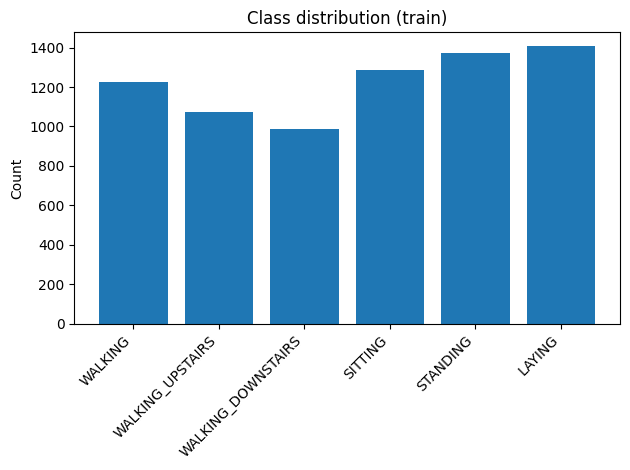

In [ ]:
class_names = [id2activity[i] for i in range(6)]


def plot_class_counts(y, title, class_names):
    y = np.asarray(y)
    K = len(class_names)
    counts = np.bincount(y.astype(int), minlength=K)

    x = np.arange(K)
    plt.figure()
    plt.bar(x, counts)
    plt.xticks(x, class_names, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_class_counts(y_train, "Class distribution (train)", class_names)


In [ ]:
eps = 1e-8 # to avoid any numerical errors

mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)          # (9,)
sigma = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + eps  # (9,)

X_train = (X_train - mu) / sigma
X_test  = (X_test  - mu) / sigma


In [ ]:
class HARDSataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, 128, 9)
        self.y = torch.tensor(y, dtype=torch.long)     # (N,)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]      # (128, 9)
        x = x.T              # (9, 128)
        return x, self.y[idx]

train_ds = HARDSataset(X_train, y_train)
test_ds  = HARDSataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch, 128, 9)
print("Batch y:", yb.shape)
print("Esempio labels batch:", yb[:10].tolist())


Batch X: torch.Size([64, 9, 128])
Batch y: torch.Size([64])
Esempio labels batch: [2, 4, 5, 4, 5, 3, 5, 3, 1, 1]


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

train_loader = DataLoader(HARDSataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(HARDSataset(X_val, y_val), batch_size=256, shuffle=False)

print("Train:", X_tr.shape, "Val:", X_val.shape)


Train: (6616, 128, 9) Val: (736, 128, 9)


In [ ]:
class BasicResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        # projection on the skip path if shape changes
        self.proj = None
        if stride != 1 or in_ch != out_ch:
            self.proj = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        skip = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.proj is not None:
            skip = self.proj(skip)

        out = F.relu(out + skip)
        return out

class TinyResNet1D(nn.Module):
    def __init__(self, in_channels=9, num_classes=6):
        super().__init__()
        # stem (1 conv)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
        )
        # 4 stages = 4 residual blocks (one per stage)
        self.b1 = BasicResBlock1D(32,  32, stride=1)  # T: 128 -> 128
        self.b2 = BasicResBlock1D(32,  64, stride=2)  # T: 128 -> 64
        self.b3 = BasicResBlock1D(64, 128, stride=2)  # T: 64  -> 32
        self.b4 = BasicResBlock1D(128,256, stride=2)  # T: 32  -> 16

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = x.mean(dim=2)          # global average pooling over time (T)
        return self.fc(x)          # logits (no softmax here)


model = TinyResNet1D().float()


#
# Loss: CrossEntropy = compares logits with class labels
# Backward: loss.backward() computes gradients
# Update: w := w - lr * grad (manual SGD)

lr = 1e-3
epochs = 10
batch_size = 64

def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


history_resnet = []

for epoch in range(1, epochs + 1):
    # train
    model.train()
    tr_loss, tr_acc, nb = 0.0, 0.0, 0


    for xb, yb in train_loader:
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        #  zero gradients
        model.zero_grad(set_to_none=True)

        # BACKWARD: compute grads d(loss)/d(params)
        loss.backward()

        # MANUAL SGD UPDATE: param := param - lr * grad
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is not None:
                    p -= lr * p.grad

        tr_loss += loss.item()
        tr_acc  += accuracy(logits, yb)
        nb += 1

    tr_loss /= nb
    tr_acc  /= nb
    resnet_model = model #to evaluete accuracy degradation

    # val
    model.eval()
    va_loss, va_acc, nb = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            va_loss += loss.item()
            va_acc  += accuracy(logits, yb)
            nb += 1
    va_loss /= nb
    va_acc  /= nb
    history_resnet.append({
        "epoch": epoch,
        "lr": lr,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": va_loss,
        "val_acc": va_acc,
     })

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")

# test
y_true_list_resnet = []
y_pred_list_resnet = []
prob_list_resnet   = []
model.eval()
te_loss, te_acc, nb = 0.0, 0.0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        te_loss += loss.item()
        te_acc  += accuracy(logits, yb)
        nb += 1

        probs = F.softmax(logits, dim=1)          # (B, K)
        preds = probs.argmax(dim=1)               # (B,)

        y_true_list_resnet.append(yb.detach())
        y_pred_list_resnet.append(preds.detach())
        prob_list_resnet.append(probs.detach())
te_loss /= nb
te_acc  /= nb
print(f"TEST | loss {te_loss:.4f} acc {te_acc:.3f}")


Epoch 01 | train loss 1.3480 acc 0.589 | val loss 0.9513 acc 0.801
Epoch 02 | train loss 0.8230 acc 0.827 | val loss 0.6572 acc 0.858
Epoch 03 | train loss 0.6298 acc 0.861 | val loss 0.5256 acc 0.901
Epoch 04 | train loss 0.5120 acc 0.893 | val loss 0.4154 acc 0.911
Epoch 05 | train loss 0.4292 acc 0.908 | val loss 0.3531 acc 0.925
Epoch 06 | train loss 0.3692 acc 0.918 | val loss 0.3006 acc 0.945
Epoch 07 | train loss 0.3236 acc 0.921 | val loss 0.2652 acc 0.947
Epoch 08 | train loss 0.2884 acc 0.932 | val loss 0.2358 acc 0.948
Epoch 09 | train loss 0.2608 acc 0.934 | val loss 0.2065 acc 0.950
Epoch 10 | train loss 0.2371 acc 0.940 | val loss 0.1956 acc 0.953
TEST | loss 0.3310 acc 0.890


In [ ]:
# ODE function: dh/dt = f(h, t)
class ODEFunc(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
        )
        # simple init (avoid all-zeros)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                nn.init.zeros_(m.bias)

    def forward(self, t, h):
        return self.net(h)


# ODE block (choose adjoint or not)
class ODEBlock(nn.Module):
    def __init__(self, odefunc, t0=0.0, t1=1.0, rtol=1e-3, atol=1e-4, method="dopri5", use_adjoint=True):
        super().__init__()
        self.odefunc = odefunc
        self.t0 = t0
        self.t1 = t1
        self.rtol = rtol
        self.atol = atol
        self.method = method
        self.use_adjoint = use_adjoint

    def forward(self, h):
        # integration interval on the same device/dtype as h
        integration_time = torch.tensor([self.t0, self.t1], device=h.device, dtype=h.dtype)

        if self.use_adjoint:
            out = odeint_adjoint(self.odefunc, h, integration_time,
                                 rtol=self.rtol, atol=self.atol, method=self.method)
        else:
            out = odeint(self.odefunc, h, integration_time,
                         rtol=self.rtol, atol=self.atol, method=self.method)

        # out has shape (2, B, hidden); take final state
        return out[-1]


# Neural ODE classifier for HAR (B,C,T) -> logits
class ODEClassifierHAR(nn.Module):
    def __init__(self, in_channels=9, num_classes=6, hidden=128, use_adjoint=True):
        super().__init__()
        # encode time-series to a single vector (like global pooling + linear)
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
        )
        self.to_hidden = nn.Linear(64, hidden)

        self.odefunc = ODEFunc(hidden)
        self.odeblock = ODEBlock(self.odefunc, t0=0.0, t1=1.0, method="dopri5", use_adjoint=use_adjoint)

        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # x: (B, C, T)
        z = self.encoder(x)        # (B, 64, T)
        z = z.mean(dim=2)          # (B, 64) global average pooling over T
        h0 = self.to_hidden(z)     # (B, hidden)

        h1 = self.odeblock(h0)     # (B, hidden)
        return self.classifier(h1) # logits


# Training loop (manual SGD)
def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


# choose adjoint True/False here
model = ODEClassifierHAR(in_channels=9, num_classes=6, hidden=128, use_adjoint=True).float()

lr = 1e-3
epochs = 20
batch_size = 64

history_ode = []

for epoch in range(1, epochs + 1):
    # ---- train ----
    model.train()
    tr_loss, tr_acc, nb = 0.0, 0.0, 0

    for xb, yb in train_loader:
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        # (A) zero gradients
        model.zero_grad(set_to_none=True)

        # (B) backward
        loss.backward()

        # (C) manual SGD update
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is not None:
                    p -= lr * p.grad

        tr_loss += loss.item()
        tr_acc  += accuracy(logits, yb)
        nb += 1

    tr_loss /= nb
    tr_acc  /= nb
    ode_model = model

    # val
    model.eval()
    va_loss, va_acc, nb = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            va_loss += loss.item()
            va_acc  += accuracy(logits, yb)
            nb += 1
    va_loss /= nb
    va_acc  /= nb

    history_ode.append({
        "epoch": epoch,
        "lr": lr,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": va_loss,
        "val_acc": va_acc,
    })

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")


# test
y_true_list_ode = []
y_pred_list_ode = []
prob_list_ode   = []
model.eval()
te_loss, te_acc, nb = 0.0, 0.0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        te_loss += loss.item()
        te_acc  += accuracy(logits, yb)
        nb += 1


        probs = F.softmax(logits, dim=1)          # (B, K)
        preds = probs.argmax(dim=1)               # (B,)

        y_true_list_ode.append(yb.detach())
        y_pred_list_ode.append(preds.detach())
        prob_list_ode.append(probs.detach())
te_loss /= nb
te_acc  /= nb
print(f"TEST | loss {te_loss:.4f} acc {te_acc:.3f}")




Epoch 01 | train loss 1.6728 acc 0.335 | val loss 1.5852 acc 0.395
Epoch 02 | train loss 1.5292 acc 0.463 | val loss 1.4572 acc 0.546
Epoch 03 | train loss 1.4157 acc 0.585 | val loss 1.3527 acc 0.600
Epoch 04 | train loss 1.3231 acc 0.628 | val loss 1.2715 acc 0.634
Epoch 05 | train loss 1.2497 acc 0.651 | val loss 1.1928 acc 0.666
Epoch 06 | train loss 1.1793 acc 0.679 | val loss 1.1336 acc 0.702
Epoch 07 | train loss 1.1151 acc 0.702 | val loss 1.0718 acc 0.712
Epoch 08 | train loss 1.0581 acc 0.735 | val loss 1.0145 acc 0.756
Epoch 09 | train loss 1.0064 acc 0.760 | val loss 0.9703 acc 0.764
Epoch 10 | train loss 0.9605 acc 0.774 | val loss 0.9224 acc 0.792
Epoch 11 | train loss 0.9179 acc 0.784 | val loss 0.8788 acc 0.797
Epoch 12 | train loss 0.8771 acc 0.804 | val loss 0.8475 acc 0.822
Epoch 13 | train loss 0.8443 acc 0.817 | val loss 0.8131 acc 0.837
Epoch 14 | train loss 0.8116 acc 0.823 | val loss 0.7805 acc 0.849
Epoch 15 | train loss 0.7836 acc 0.840 | val loss 0.7494 acc 0

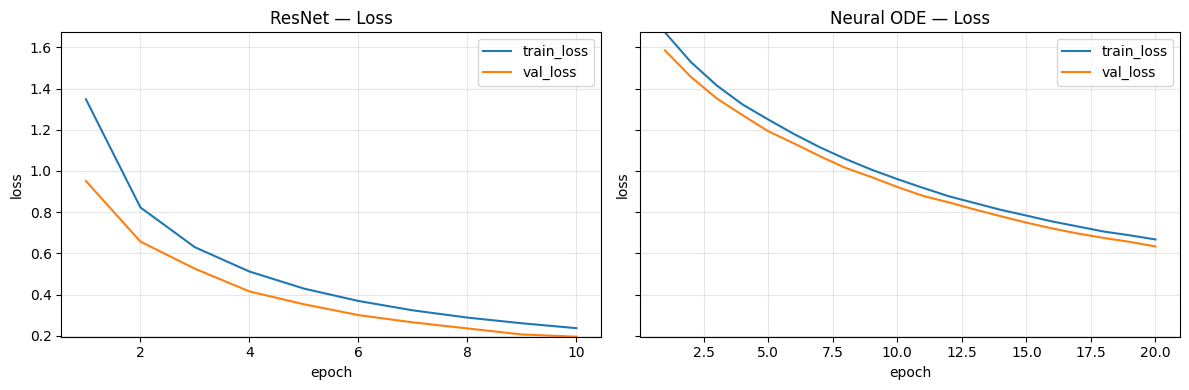

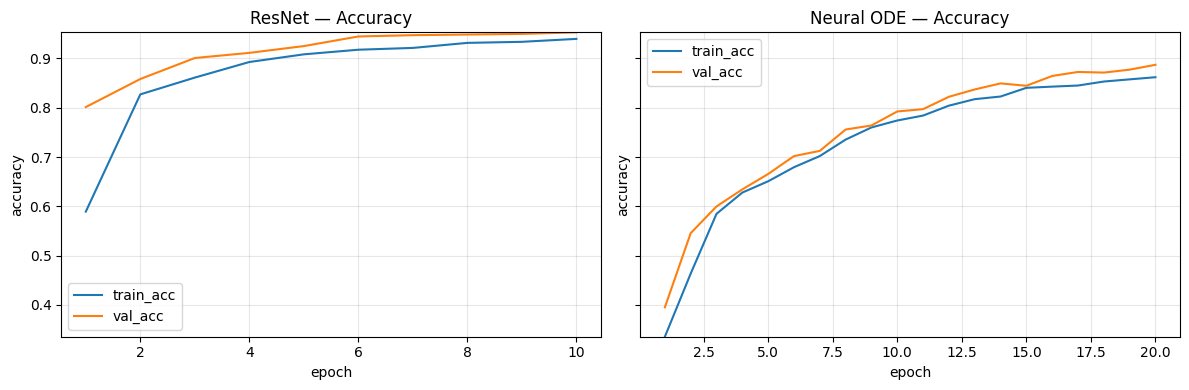

<Figure size 640x480 with 0 Axes>

In [ ]:
def _to_df(history):
    df = pd.DataFrame(history).copy()
    if "epoch" in df.columns:
        df = df.sort_values("epoch")
    return df.reset_index(drop=True)

def compare_histories_side_by_side(history_A, history_B, name_A="Model A", name_B="Model B"):
    dfA, dfB = _to_df(history_A), _to_df(history_B)

    #LOSS: same y-limits across both models (train+val)
    loss_cols = ["train_loss", "val_loss"]
    yloss_min = min(dfA[loss_cols].min().min(), dfB[loss_cols].min().min())
    yloss_max = max(dfA[loss_cols].max().max(), dfB[loss_cols].max().max())

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for df, title, a in [(dfA, name_A, ax[0]), (dfB, name_B, ax[1])]:
        a.plot(df["epoch"], df["train_loss"], label="train_loss")
        a.plot(df["epoch"], df["val_loss"],   label="val_loss")
        a.set_title(f"{title} — Loss")
        a.set_xlabel("epoch")
        a.set_ylabel("loss")
        a.set_ylim(yloss_min, yloss_max)
        a.grid(True, alpha=0.3)
        a.legend()
    plt.tight_layout()
    plt.show()

    #ACC: same y-limits across both models (train+val)
    acc_cols = ["train_acc", "val_acc"]
    yacc_min = min(dfA[acc_cols].min().min(), dfB[acc_cols].min().min())
    yacc_max = max(dfA[acc_cols].max().max(), dfB[acc_cols].max().max())

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for df, title, a in [(dfA, name_A, ax[0]), (dfB, name_B, ax[1])]:
        a.plot(df["epoch"], df["train_acc"], label="train_acc")
        a.plot(df["epoch"], df["val_acc"],   label="val_acc")
        a.set_title(f"{title} — Accuracy")
        a.set_xlabel("epoch")
        a.set_ylabel("accuracy")
        a.set_ylim(yacc_min, yacc_max)
        a.grid(True, alpha=0.3)
        a.legend()
    plt.tight_layout()
    plt.show()

compare_histories_side_by_side(history_resnet, history_ode, "ResNet", "Neural ODE")
fig = plt.gcf()                  # get current figure
fig.savefig("history_comparison.png", dpi=200, bbox_inches="tight")

In [ ]:
# build confusion matrix from (y_true_list, y_pred_list)
def confusion_from_lists(y_true_list, y_pred_list, K=None):
    y_true = torch.cat(y_true_list, dim=0)
    y_pred = torch.cat(y_pred_list, dim=0)

    if K is None:
        K = int(torch.max(y_true).item()) + 1

    cm = torch.zeros((K, K), dtype=torch.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t.item()), int(p.item())] += 1
    return cm

# compute both confusion matrices
cm_resnet = confusion_from_lists(y_true_list_resnet, y_pred_list_resnet)
cm_ode    = confusion_from_lists(y_true_list_ode,    y_pred_list_ode, K=cm_resnet.shape[0])

print("Confusion matrix RESNET (rows=true, cols=pred):")
print(cm_resnet)
print("\nConfusion matrix ODE (rows=true, cols=pred):")
print(cm_ode)


Confusion matrix RESNET (rows=true, cols=pred):
tensor([[469,   1,  26,   0,   0,   0],
        [ 11, 421,  39,   0,   0,   0],
        [ 36,   1, 383,   0,   0,   0],
        [ 24,   3,   0, 370,  92,   2],
        [  4,   0,   0,  73, 455,   0],
        [  0,  27,   0,   0,   0, 510]])

Confusion matrix ODE (rows=true, cols=pred):
tensor([[393,  41,  62,   0,   0,   0],
        [ 70, 353,  48,   0,   0,   0],
        [ 63,  24, 333,   0,   0,   0],
        [  2,   3,   0, 346, 140,   0],
        [  3,   0,   0,  80, 449,   0],
        [  0,  27,   0,   0,   0, 510]])


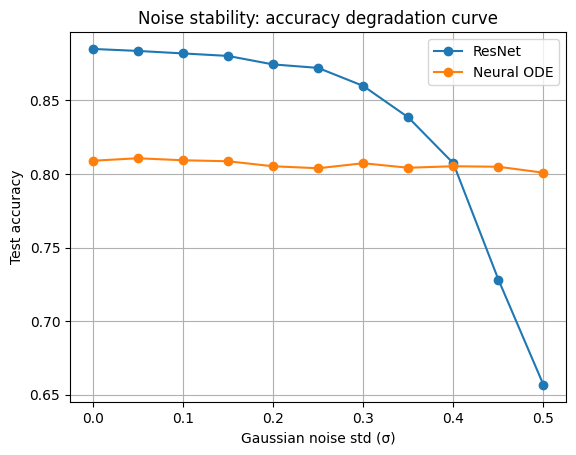

Noise stability (normalized): higher nAUC_rel = more stable; lower rel-drop/rel-slope = more stable
     model nAUC_rel (avg retained acc) rel-drop@σmax rel-slope
    ResNet                      0.9488        0.2581    0.5161
Neural ODE                      0.9969        0.0101    0.0201


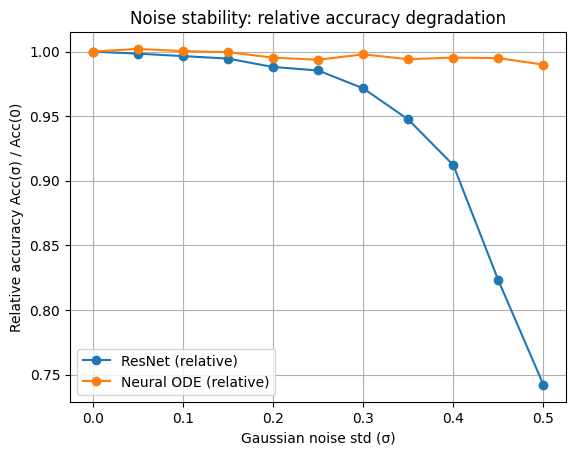

In [ ]:
# Noise robustness curve

try:

    has_resnet = ("resnet_model" in globals())
    has_ode    = ("ode_model" in globals()) or ("model" in globals())  # last trained is ODE

    if has_resnet and ("test_loader" in globals()):
        ode_m = globals().get("ode_model", globals().get("model"))
        res_m = globals().get("resnet_model")

        device = next(res_m.parameters()).device
        ode_m = ode_m.to(device)
        res_m = res_m.to(device)
        ode_m.eval(); res_m.eval()

        def eval_acc_with_noise(model_, loader_, sigma):
            correct, total = 0, 0
            with torch.no_grad():
                for xb, yb in loader_:
                    xb = xb.to(device)
                    yb = yb.to(device)
                    xb_noisy = xb + sigma * torch.randn_like(xb)
                    logits = model_(xb_noisy)
                    pred = logits.argmax(dim=1)
                    correct += (pred == yb).sum().item()
                    total += yb.numel()
            return correct / total

        sigmas = np.linspace(0.0, 0.5, 11)
        acc_res = [eval_acc_with_noise(res_m, test_loader, float(s)) for s in sigmas]
        acc_ode = [eval_acc_with_noise(ode_m, test_loader, float(s)) for s in sigmas]

        plt.figure()
        plt.plot(sigmas, acc_res, marker="o", label="ResNet")
        plt.plot(sigmas, acc_ode, marker="o", label="Neural ODE")
        plt.xlabel("Gaussian noise std (σ)")
        plt.ylabel("Test accuracy")
        plt.title("Noise stability: accuracy degradation curve")
        plt.grid(True)
        plt.legend()
        plt.show()

    else:
        print("[Optional noise test skipped]")
except Exception as e:
    print("[Optional noise test skipped due to error]", repr(e))

sigmas = np.asarray(sigmas, dtype=float)
acc_res = np.asarray(acc_res, dtype=float)
acc_ode = np.asarray(acc_ode, dtype=float)

sigma_max = float(sigmas.max())

# Relative accuracy curves (normalize by clean accuracy)
rel_res = acc_res / acc_res[0]
rel_ode = acc_ode / acc_ode[0]

def rel_metrics(sigmas, rel_acc):
    # normalized area = average relative accuracy over [0, sigma_max]
    auc_rel = np.trapezoid(rel_acc, sigmas)
    nAUC_rel = auc_rel / sigma_max if sigma_max > 0 else np.nan

    rel_drop = 1.0 - rel_acc[-1]                 # = 1 - Acc(smax)/Acc(0)
    rel_slope = rel_drop / sigma_max if sigma_max > 0 else np.nan
    return nAUC_rel, rel_drop, rel_slope

nAUC_r, drop_r, slope_r = rel_metrics(sigmas, rel_res)
nAUC_o, drop_o, slope_o = rel_metrics(sigmas, rel_ode)

df = pd.DataFrame([
    {"model": "ResNet",    "nAUC_rel (avg retained acc)": nAUC_r, "rel-drop@σmax": drop_r, "rel-slope": slope_r},
    {"model": "Neural ODE","nAUC_rel (avg retained acc)": nAUC_o, "rel-drop@σmax": drop_o, "rel-slope": slope_o},
])

df_fmt = df.copy()
for c in df.columns[1:]:
    df_fmt[c] = df_fmt[c].map(lambda x: f"{x:.4f}")

print("Noise stability (normalized): higher nAUC_rel = more stable; lower rel-drop/rel-slope = more stable")
print(df_fmt.to_string(index=False))

# Plot relative degradation
plt.figure()
plt.plot(sigmas, rel_res, marker="o", label="ResNet (relative)")
plt.plot(sigmas, rel_ode, marker="o", label="Neural ODE (relative)")
plt.xlabel("Gaussian noise std (σ)")
plt.ylabel("Relative accuracy Acc(σ) / Acc(0)")
plt.title("Noise stability: relative accuracy degradation")
plt.grid(True)
plt.legend()
plt.show()
